In [1]:
%load_ext autoreload
%autoreload 2
from tools.emuse_utils import DiscreteLatentSpace
import pickle
import pandas as pd

from sklearn.datasets import load_digits

# load the digits dataset
digits = load_digits()

labels = digits['target']
# the data is in the same order as embedding (that was the training data)

# Create a DiscreteLatentSpace object with loading /gamma/Dropbox (GIN)/EMUSE/mnist_umap_42.sav and /gamma/Dropbox (GIN)/EMUSE/mnist_embedding_42.csv

# Load the UMAP embedding to numpy
embedding = pd.read_csv('/gamma/Dropbox (GIN)/EMUSE/mnist_embedding_42.csv', header=None)
embedding = embedding.values

# Load the UMAP model
with open('/gamma/Dropbox (GIN)/EMUSE/mnist_umap_42.sav', 'rb') as f:
    umap_model = pickle.load(f)
    
# Create the DiscreteLatentSpace object
dls = DiscreteLatentSpace(umap_model, embedding, margin=10)

There is an overlap of 9.74% points in the discrete space
The number of cells in the discrete space is 917910
The shape of the discrete space is (930, 987)
Maximum in each dimension: 18.60238075256348
delete_heatmap: No heatmap with the name test_heatmap exists


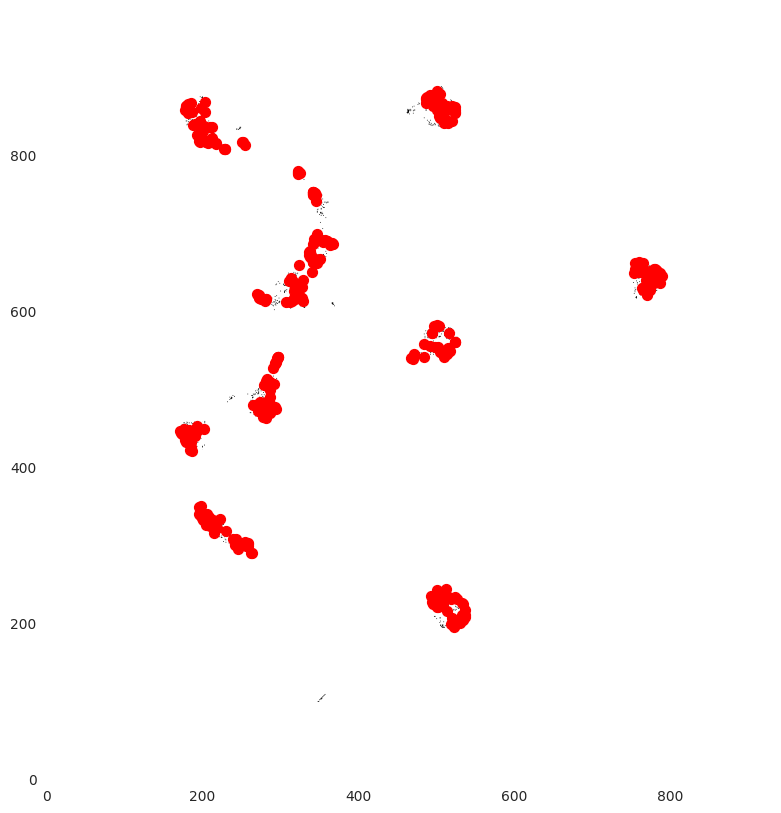

Smoothing the discrete space with a sigma of 21.233045007200477
Shape of the smoothed space: (359, 930, 987)
Sigma tuple: (0, 21.233045007200477, 21.233045007200477)
Shape of the smoothed n+1 dim discrete space: (359, 930, 987)
Max value in the smoothed_nplusone_dim_discrete_space: 1.0


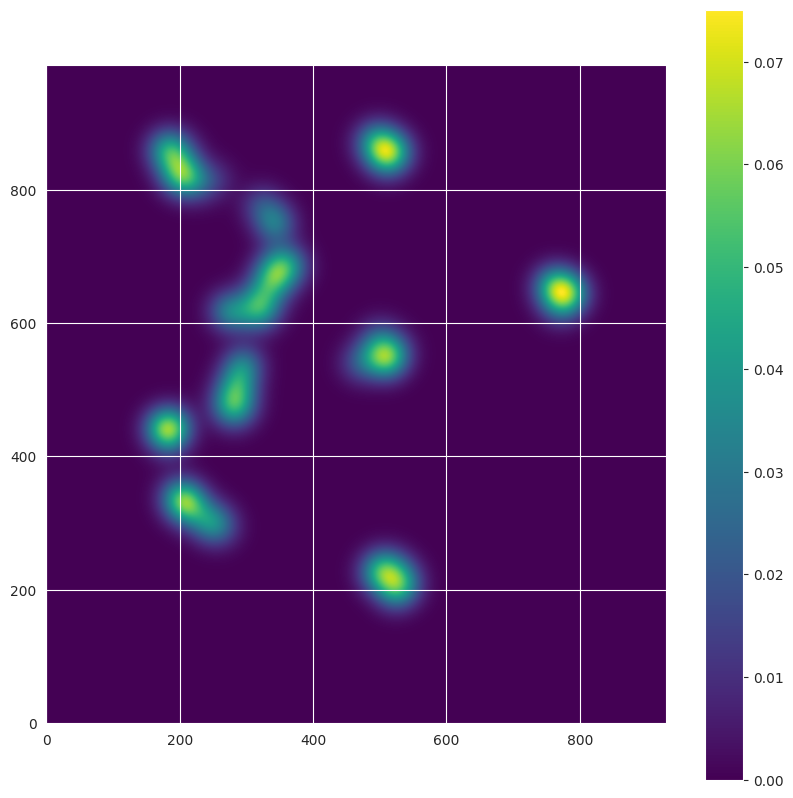

unique_vectors shape: (369031, 359)
vectors shape: (917910, 359)


/home/chrisfoulon/miniconda3/lib/python3.11/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))


In [72]:
# create a heatmap in the dls using self create_heatmap_spaces(self, embeddings, scores, name) with the last 10% of the embeddings
test_sub_embedding = embedding[-int(embedding.shape[0] * 0.2):]
# use the label as the score for the heatmap
sub_labels = labels[-int(embedding.shape[0] * 0.2):]
# normalise the labels between 0 and 1
sub_labels = (sub_labels - sub_labels.min()) / (sub_labels.max() - sub_labels.min())


# create the rescaled and discrete embeddings
dls.rescale_embedding(dls.raw_embeddings)
# dls.create_inverse_rescaled_embedding()
dls.create_discrete_space(dls.rescaled_embeddings, 10)
# delete the heatmap if it already exists
dls.delete_heatmap('test_heatmap')
dls.create_heatmap_spaces(test_sub_embedding, sub_labels, 'test_heatmap')

# plot the heatmap
dls.plot_discrete_embedding(heatmap_name='test_heatmap')

dls.plot_heatmap('test_heatmap', 50)

heatmap = dls.heatmaps['test_heatmap']

# Now I want to use compute_stats_on_smoothed_nplusone_dim_discrete_space and then display the statistics and the corrected p-values heatmap
from tools.emuse_utils import compute_stats_on_smoothed_nplusone_dim_discrete_space, compute_stats_on_corrected_clusters

multiple_comparison_correction = 'sidak'
print(f'Heatmap shape: {heatmap.shape}')
statistics, pvalues, corrected_pvalues, _ = compute_stats_on_smoothed_nplusone_dim_discrete_space(heatmap, sub_labels, 'pearson', multiple_comparison_correction)
print(f'Statistics shape: {statistics.shape}')
statistics_clu, pvalues_clu, corrected_pvalues_clu, _ = compute_stats_on_corrected_clusters(heatmap, sub_labels, 'pearson', multiple_comparison_correction)
print(f'Statistics clusters shape: {statistics_clu.shape}')



 Min max corrected_pvalues: nan nan
<class 'numpy.ndarray'>
Shape corrected_pvalues: (930, 987)
Number of non-Nan values: 373015


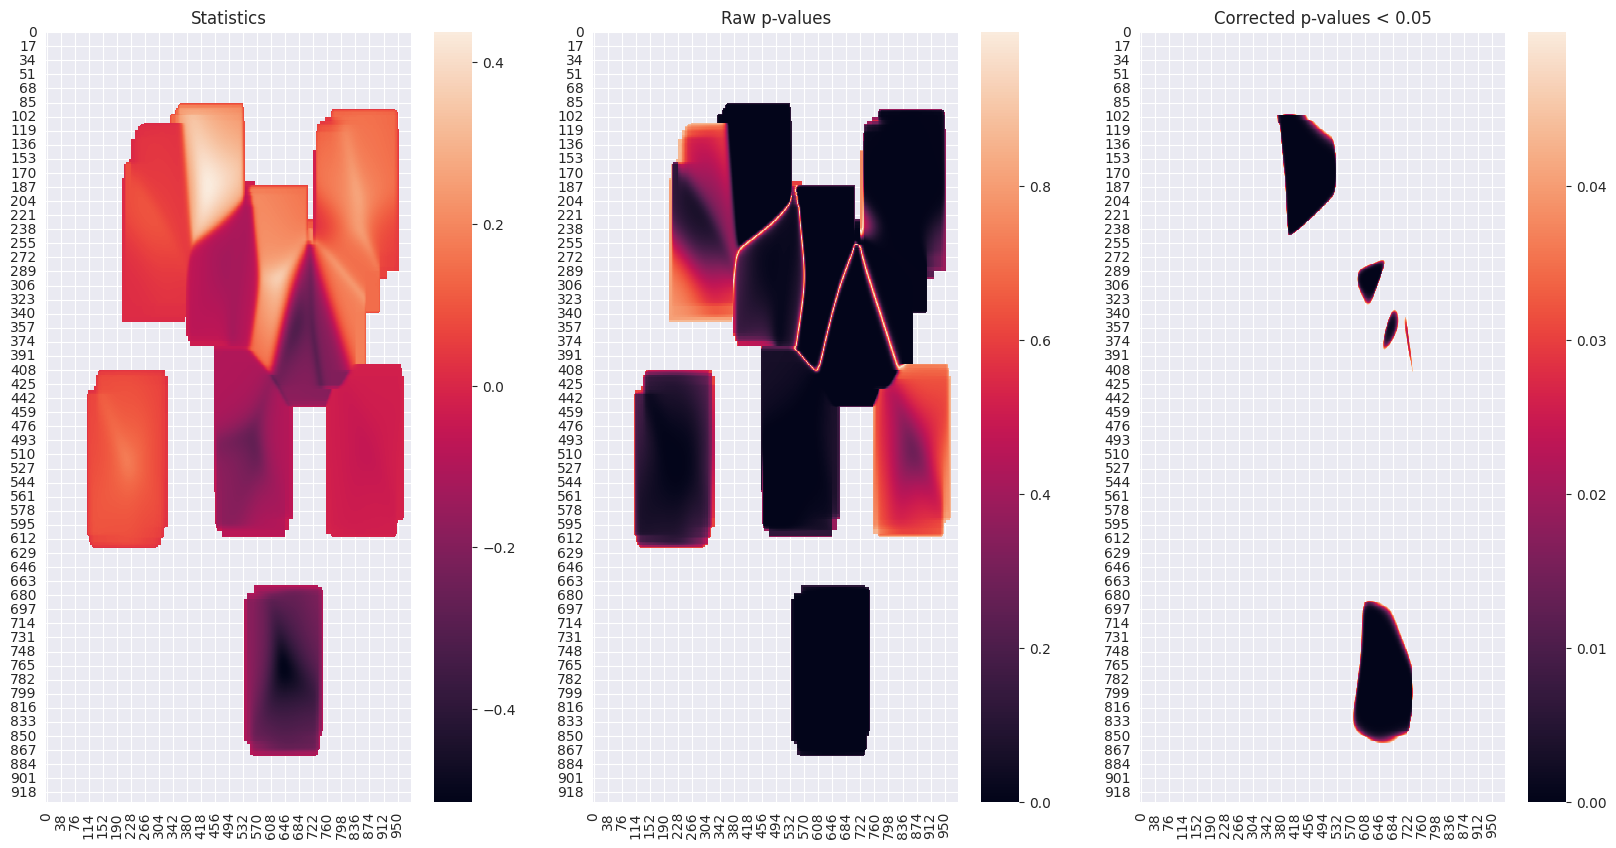

In [74]:
# plot the statistics and the corrected p-values heatmap (it is not from the dls class!)
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(1, 3, figsize=(20, 10))

sns.heatmap(statistics, ax=ax[0])
ax[0].set_title('Statistics')

# raw p-values
sns.heatmap(pvalues, ax=ax[1])
ax[1].set_title('Raw p-values')

print(f' Min max corrected_pvalues: {corrected_pvalues.min()} {corrected_pvalues.max()}')

print(type(corrected_pvalues))
print(f'Shape corrected_pvalues: {corrected_pvalues.shape}')

# check if there are any non-Nan values
print(f'Number of non-Nan values: {np.sum(~np.isnan(corrected_pvalues))}')

if np.sum(~np.isnan(corrected_pvalues)) > 0:
    masked_pvalues = np.where(corrected_pvalues < 0.05, corrected_pvalues, np.nan)
    sns.heatmap(masked_pvalues, ax=ax[2])
    ax[2].set_title('Corrected p-values < 0.05')
else:
    masked_pvalues = np.where(pvalues < 0.05, pvalues, np.nan)
    sns.heatmap(masked_pvalues, ax=ax[2])
    ax[2].set_title('Raw p-values < 0.05')

plt.show()



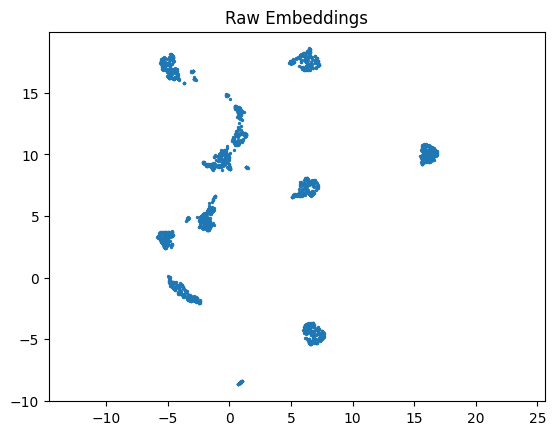

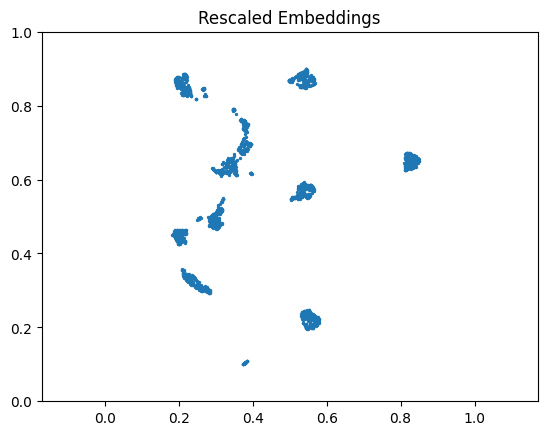

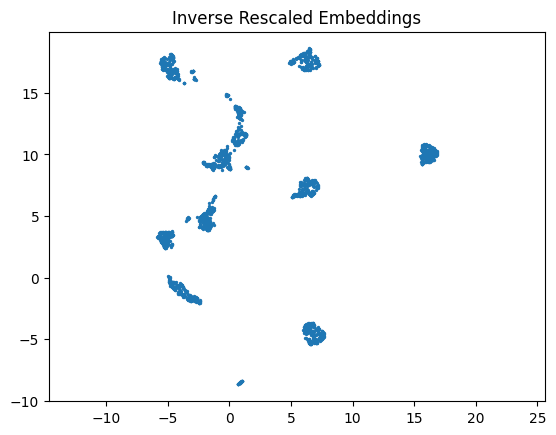

There is an overlap of 9.74% points in the discrete space
The number of cells in the discrete space is 917910
The shape of the discrete space is (930, 987)
Maximum in each dimension: 18.60238075256348


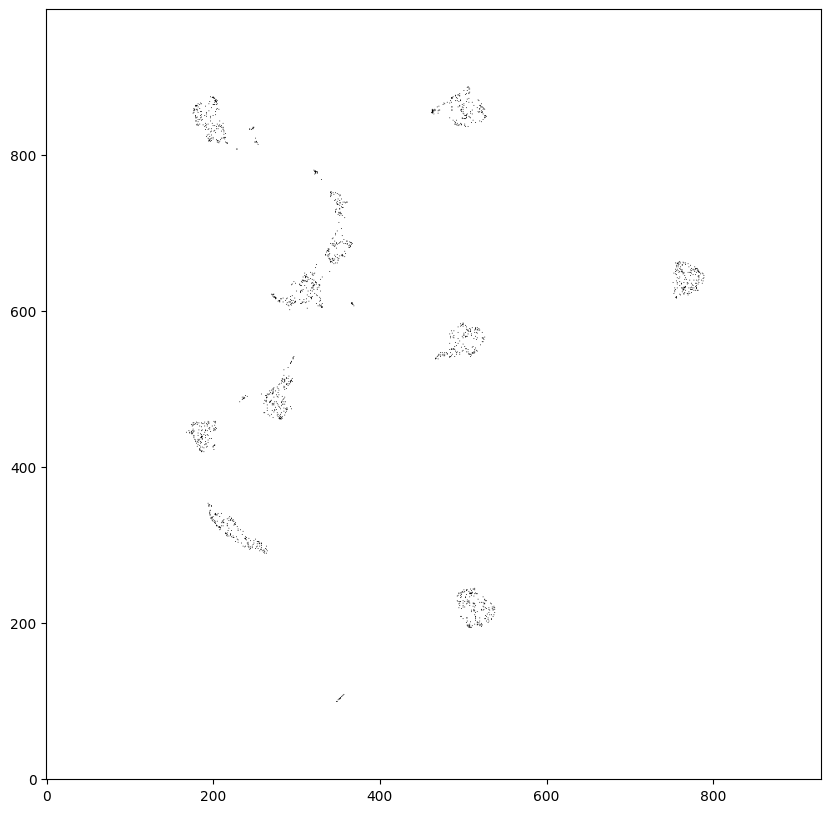

There is an overlap of 11.57% points in the discrete space
The number of cells in the discrete space is 722750
The shape of the discrete space is (826, 875)
Maximum in each dimension: 18.60238075256348


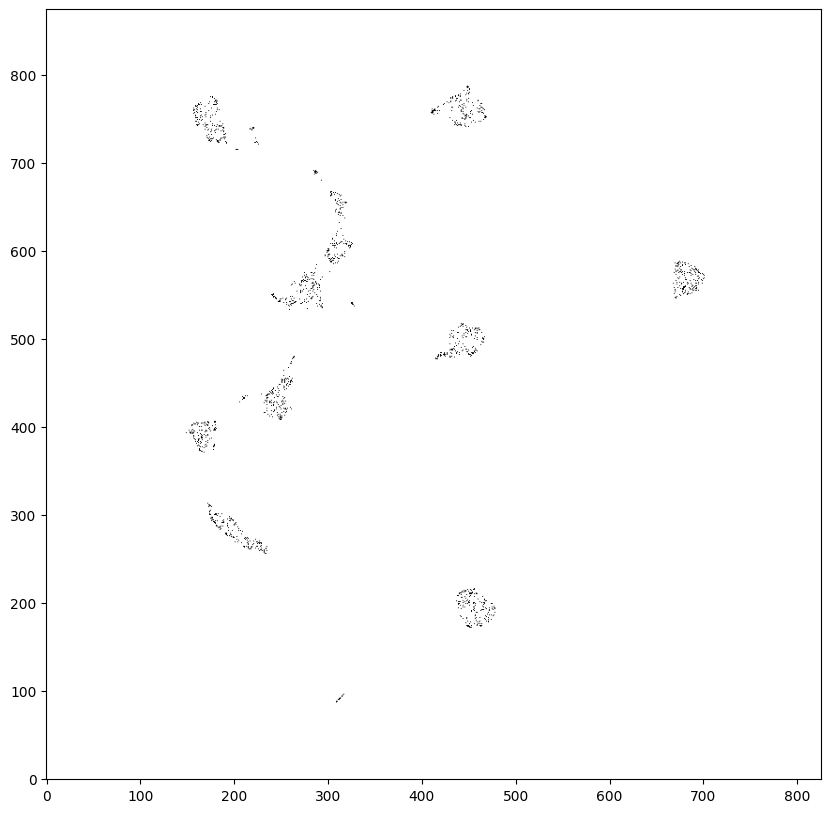

There is an overlap of 11.69% points in the discrete space
The number of cells in the discrete space is 722700
The shape of the discrete space is (825, 876)
Maximum in each dimension: 18.60238075256348


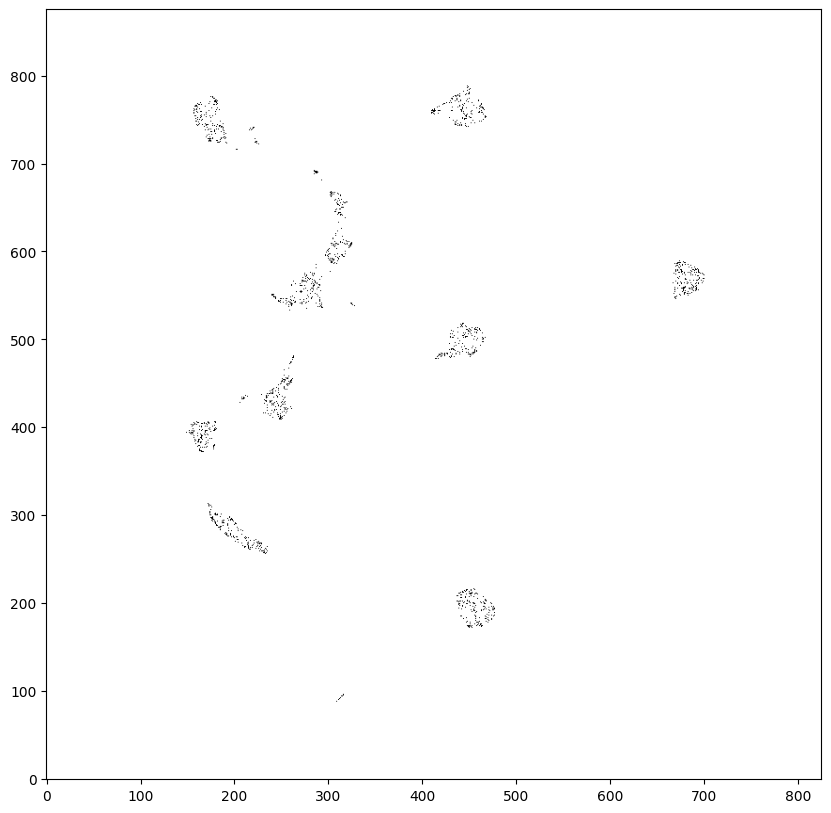

In [223]:
# plot the different versions of the embeddings in the latent space
dls.plot_raw_embedding()

dls.plot_rescaled_embedding()

dls.plot_inverse_rescaled_embedding()

dls.plot_discrete_embedding(10)

dls.plot_discrete_embedding(None, (826, 875))
dls.plot_discrete_embedding(None, (825, 876))


In [8]:
import os
import glob
from PIL import Image
import numpy as np
import pandas as pd

# image_paths_list_to_matrix
images_folder = "/gamma/Dropbox (GIN)/EMUSE/faces/CFD Version 3.0/Images"

# List all image files in the directory and its subdirectories
image_files = glob.glob(os.path.join(images_folder, '**', '*.*'), recursive=True)

# Filter the image files with a filename ending with "-N"
filtered_files = [f for f in image_files if os.path.splitext(os.path.basename(f))[0].endswith('-N')]

print(len(filtered_files))
print(f'Unique files names (without folder): {len(set([os.path.basename(f) for f in filtered_files]))}')

# save filtered_files as a csv
filtered_files_df = pd.DataFrame(filtered_files, columns=['image_path'])
filtered_files_df.to_csv('/gamma/Dropbox (GIN)/EMUSE/faces/filtered_files.csv', index=False)


# print the different resolutions (unique ones) of the images
# resolutions = set([np.array(Image.open(f)).shape for f in filtered_files])
# print(resolutions)


831
Unique files names (without folder): 831


In [4]:
from tqdm import tqdm
import importlib
import tools.inputs_utils

importlib.reload(tools.inputs_utils)

# images_list = [Image.open(img_path) for img_path in filtered_files]
# faces_input_matrix = image_paths_list_to_matrix(filtered_files, rescale=True)

def process_images(image_list, target_size=(128, 128)):
    images = []
    for img_path in tqdm(image_list):
        with Image.open(img_path) as img:
            img = img.resize(target_size)
            img_array = np.array(img, dtype=np.uint8)  # Use uint8 to save memory
            images.append(img_array.flatten())  # Flatten if necessary or adapt based on UMAP needs
    return np.array(images)

faces_input_matrix = process_images(filtered_files, (2407, 1662))

100%|██████████| 831/831 [01:53<00:00,  7.34it/s]


In [8]:
import scipy.sparse as sparse
# create an output folder for the trained umap and embeddings
output_folder = '/gamma/Dropbox (GIN)/EMUSE/faces_umap_output_42'
seed = 42

# create the output folder if it does not exist
if not os.path.exists(output_folder):
    os.makedirs(output_folder)
    
# faces_input_matrix = sparse.csr_matrix(faces_input_matrix, dtype=np.uint8)
    
# save the faces_input_matrix
np.save(os.path.join(output_folder, 'faces_input_matrix.npy'), faces_input_matrix)
# sparse.save_npz(os.path.join(output_folder, 'faces_input_matrix.npz'), faces_input_matrix)

MemoryError: Unable to allocate 148. GiB for an array with shape (9945723878, 2) and data type int64

In [ ]:
# train the umap model
from umap import UMAP

umap_model = UMAP(random_state=seed, verbose=True, n_neighbors=15, min_dist=0.1, n_components=2, metric='euclidean')
umap_embedding = umap_model.fit(faces_input_matrix)

In [12]:
import pickle
# save the umap model
with open(os.path.join(output_folder, 'faces_umap_42.sav'), 'wb') as f:
    pickle.dump(umap_model, f)
    
# save the umap embedding
np.savetxt(os.path.join(output_folder, 'faces_embedding_42.csv'), umap_embedding.embedding_, delimiter=',')

In [5]:
import os 
import pandas as pd

output_folder = '/gamma/Dropbox (GIN)/EMUSE/faces_umap_output_42'

faces_embedding = pd.read_csv(os.path.join(output_folder, 'faces_embedding_42.csv'), header=None)

print(faces_embedding.shape)

(831, 2)


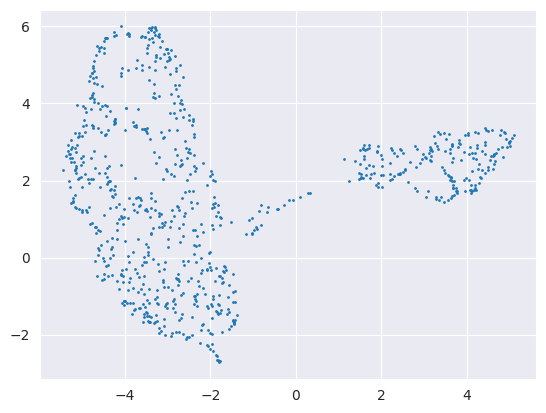

In [6]:
# plot the umap embedding
import matplotlib.pyplot as plt

plt.scatter(faces_embedding[0], faces_embedding[1], s=1)
plt.show()


In [9]:
# load /gamma/Dropbox (GIN)/EMUSE/faces/CFD Version 3.0/CFD 3.0 Norming Data and Codebook.xlsx
info_dataframe = pd.read_excel('/gamma/Dropbox (GIN)/EMUSE/faces/CFD Version 3.0/CFD 3.0 Norming Data and Codebook.xlsx', sheet_name=None, header=7)

# print sheet names
print(list(info_dataframe.keys()))

# create a dataframe maching the image names (filenames in filtered_files) with the "Model" column in all the "Norming Data" sheets. The filename should contain the "Model" column in the "Norming Data" sheets
import os
import pandas as pd
from pathlib import Path

# Get the common columns across all dataframes
common_columns = set(info_dataframe[list(info_dataframe.keys())[1]].columns)
for sheet_name, df in info_dataframe.items():
    if 'Norming Data' not in sheet_name:
        continue
    # print first 5 columns
    # print(df.columns[:5])
    common_columns.intersection_update(df.columns)
    
common_columns = list(common_columns)

# print(common_columns)

model_data = []
for sheet_name, df in info_dataframe.items():
    if "U.S. Norming Data" in sheet_name:
        # Only append the common columns
        model_data.append(df[common_columns])

# Create a new dataframe that contains the common data from all sheets
model_df = pd.concat(model_data, ignore_index=True)

# remove the rows with NaN values for Model
model_df = model_df.dropna(subset=['Model'])

# print(model_df.columns)

# print(f'Model in columns {"Model" in model_df.columns}')
# print(len(model_df['Model'].unique()))

path_model_match = {}

# Match the filename with the "Model" column
for img_path in filtered_files:
    img_name = Path(img_path).name
    found = False
    for model in model_df['Model']:
        # print(model)
        if model in img_name or model in img_name.replace('-', '', 2):
            if found:
                print(f"Multiple matches for {img_name}")
                break
            path_model_match[img_name] = model
            found = True
    if not found:
        print(f"No match for {img_name}")
        
# save the path_model_match dictionary in a json
import json

with open(os.path.join(output_folder, 'path_model_match.json'), 'w') as f:
    json.dump(path_model_match, f, indent=4)
    
# save the model_df dataframe filtered with only the matched models in a csv
model_df = model_df[model_df['Model'].isin(path_model_match.values())]
print(model_df.shape)
model_df.to_csv(os.path.join(output_folder, 'models_merged_df.csv'), index=False)


/home/chrisfoulon/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


['CFD 3.0 Codebook', 'CFD U.S. Norming Data', 'CFD-MR U.S. Norming Data', 'CFD-I U.S. Norming Data', 'CFD-I INDIA Norming Data']
No match for CFD-IM-719-221-N.jpg
No match for CFD-IM-638-250-2-N.jpg
No match for CFD-IF-644-306-2-N.jpg
No match for CFD-IF-714-008-2-N.jpg
No match for CFD-IF-677-452-2-N.jpg
(826, 118)


In [49]:
# Now I want to create a DiscreteLatentSpace object with the faces umap model and embedding
from tools.emuse_utils import DiscreteLatentSpace
import pickle
import pandas as pd
import os

output_folder = '/gamma/Dropbox (GIN)/EMUSE/faces_umap_output_42'
# Load the UMAP embedding to numpy
embedding = pd.read_csv(os.path.join(output_folder, 'faces_embedding_42.csv'), header=None)
embedding = embedding.values

# Load the UMAP model
# with open(os.path.join(output_folder, 'faces_umap_42.sav'), 'rb') as f:
#     umap_model = pickle.load(f)
    
umap_model = None
    
filtered_files_df = pd.read_csv('/gamma/Dropbox (GIN)/EMUSE/faces/filtered_files.csv')

print(filtered_files_df.columns)

# Create the DiscreteLatentSpace object
dls = DiscreteLatentSpace(umap_model, embedding, margin=5)


Index(['image_path'], dtype='object')


There is an overlap of 4.93% points in the discrete space
The number of cells in the discrete space is 68000
The shape of the discrete space is (250, 272)
Maximum in each dimension: 6.000002384185791
Size of Attractive column: (826,)
Embedding shape: (831, 2)
Attractive embedding shape: (826, 2)


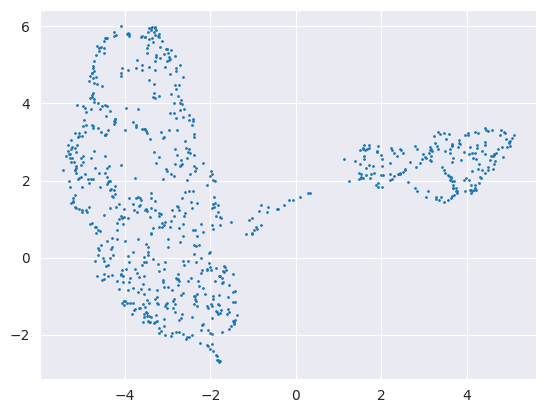

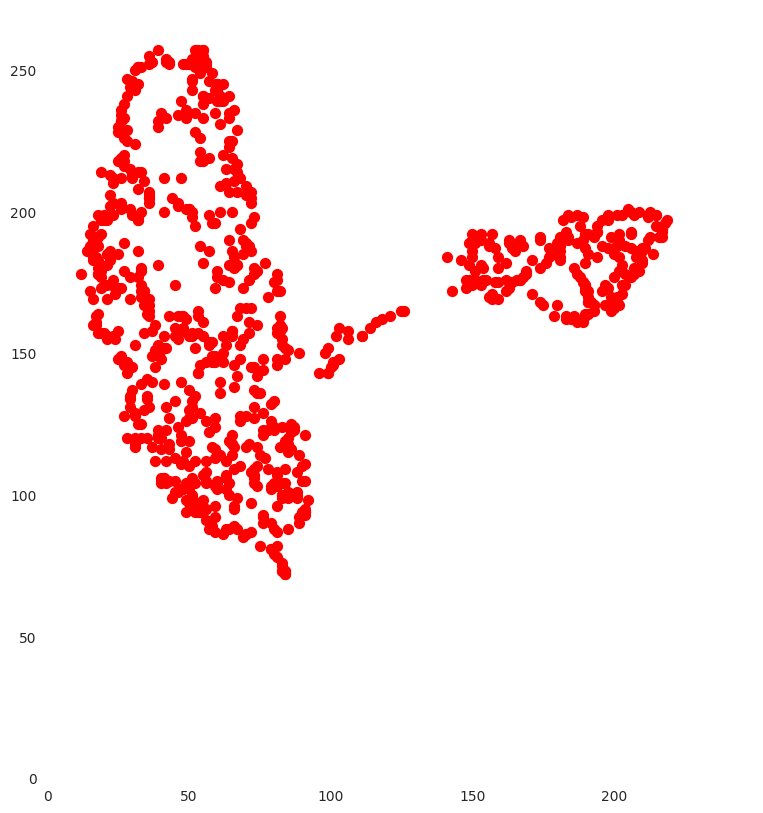

In [52]:
import json
from pathlib import Path

# Now I want to create the different spaces to finally create a heatmap and display the corrected p-values heatmap

dls.rescale_embedding(dls.raw_embeddings)
dls.create_discrete_space(dls.rescaled_embeddings, 5)

# create a heatmap in the dls using self create_heatmap_spaces(self, embeddings, scores, name) 


path_model_match = json.load(open(os.path.join(output_folder, 'path_model_match.json')))
model_df = pd.read_csv(os.path.join(output_folder, 'models_merged_df.csv'))
# use the "Attractive" column in the model_df as the score for the heatmap
sub_labels = model_df['Attractive']
# Normalize the 'Attractive' column between 0 and 1 using 1 and 7 as boundaries
model_df['Attractive'] = (model_df['Attractive'] - 1) / (7 - 1)

print(f'Size of Attractive column: {model_df["Attractive"].shape}')

# the umap was trained with all the file but path_model_match contains only the matched files
# so I need to filter the embedding.
print(f'Embedding shape: {embedding.shape}')
attractive_embedding = embedding[[i for i, img_name in enumerate(filtered_files_df['image_path']) if Path(img_name).name in path_model_match.keys()]]
print(f'Attractive embedding shape: {attractive_embedding.shape}')

# plot attractive_embedding
plt.scatter(attractive_embedding[:, 0], attractive_embedding[:, 1], s=1)
plt.show()

# create the heatmap and all the spaces needed to compute the corrected p-values
dls.delete_heatmap('attractive_heatmap')
dls.create_heatmap_spaces(attractive_embedding, model_df['Attractive'], 'attractive_heatmap')

# create the heatmap raw, rescaled and discrete spaces
attractive_heatmap = dls.heatmaps['attractive_heatmap']

# plot the heatmap
dls.plot_discrete_embedding(heatmap_name='attractive_heatmap')

Smoothing the discrete space with a sigma of 2.1233045007200477
Shape of the smoothed space: (826, 250, 272)
Sigma tuple: (0, 2.1233045007200477, 2.1233045007200477)
Shape of the smoothed n+1 dim discrete space: (826, 250, 272)
Max value in the smoothed_nplusone_dim_discrete_space: 1.0


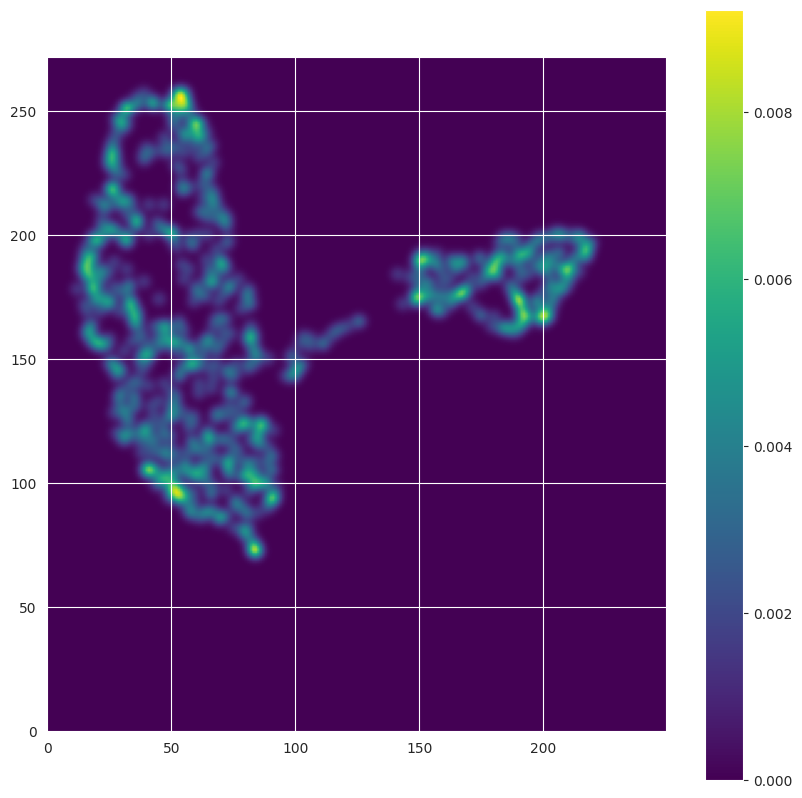

unique_vectors shape: (18276, 826)
vectors shape: (68000, 826)


/home/chrisfoulon/miniconda3/lib/python3.11/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))


 Min max corrected_pvalues: nan nan
<class 'numpy.ndarray'>
Shape corrected_pvalues: (250, 272)
Number of non-Nan values: 18580


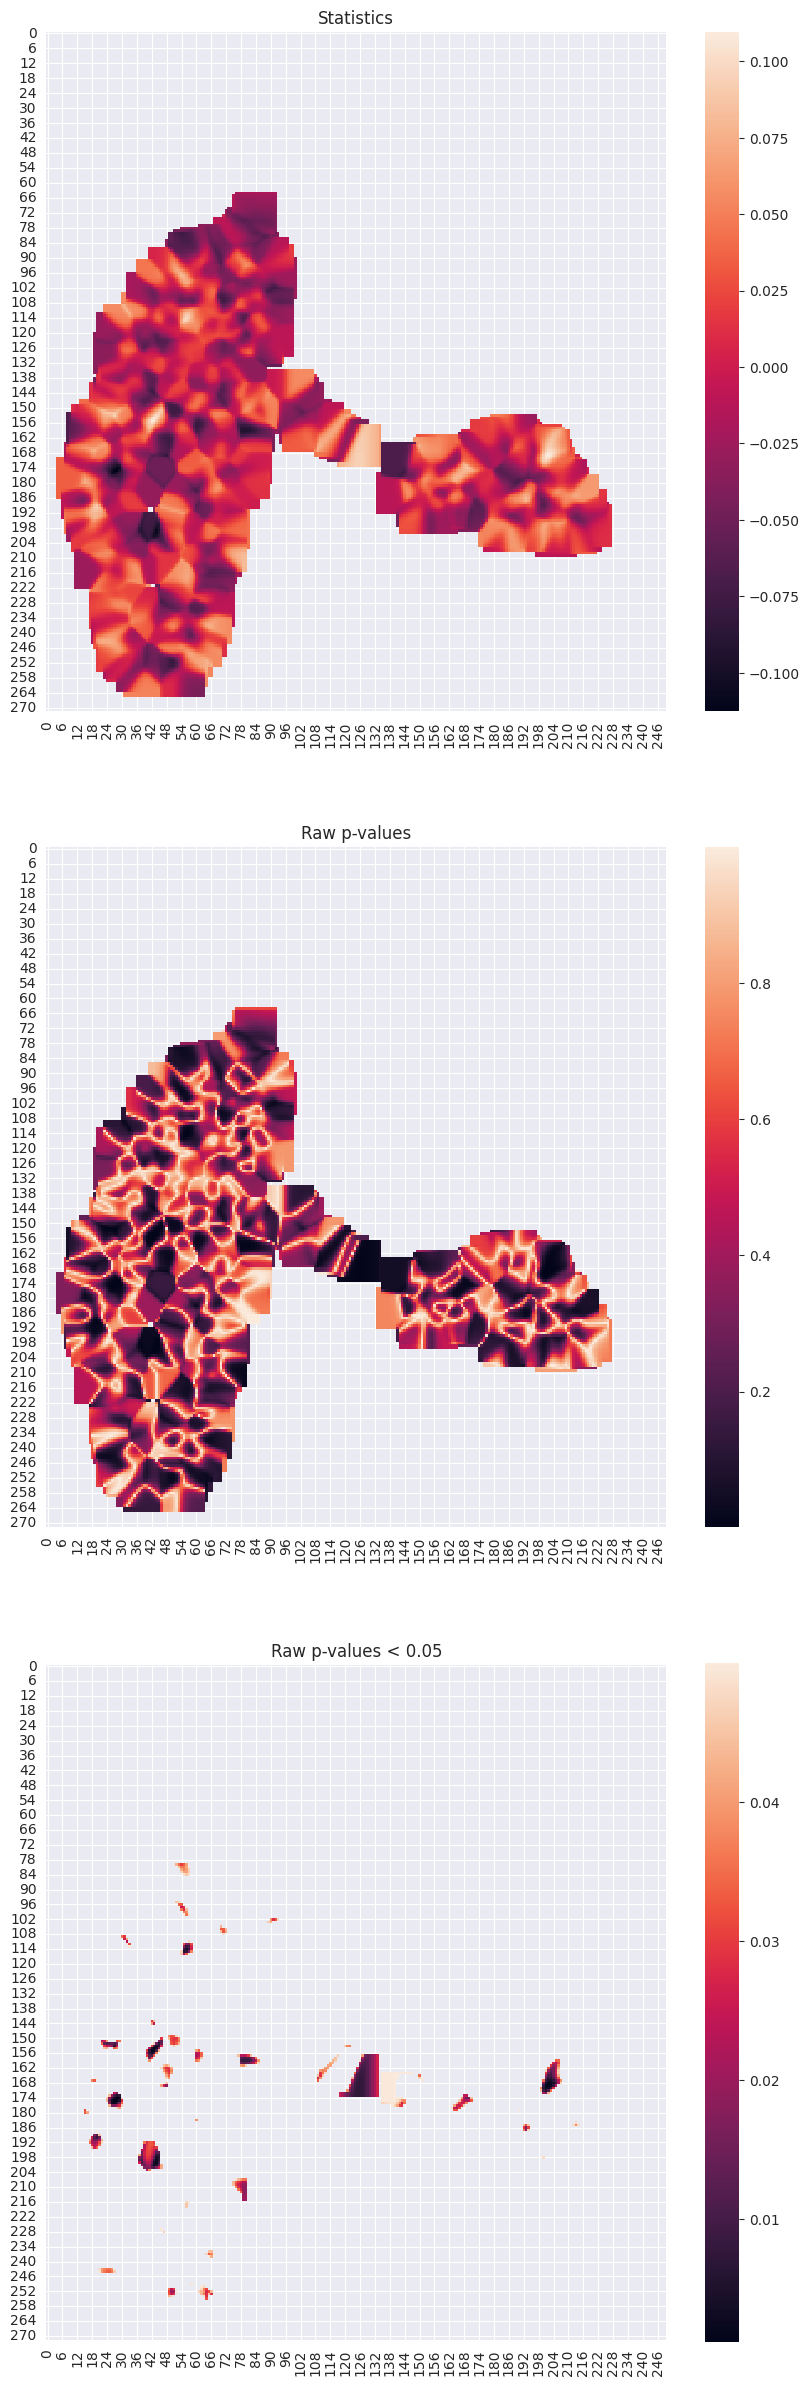

In [53]:
from tools.emuse_utils import compute_stats_on_smoothed_nplusone_dim_discrete_space, compute_stats_on_corrected_clusters

multiple_comparison_correction = 'sidak'

# plot the heatmap
dls.plot_heatmap('attractive_heatmap', 5)

statistics, pvalues, corrected_pvalues, _ = compute_stats_on_smoothed_nplusone_dim_discrete_space(attractive_heatmap, model_df['Attractive'], 'pearson', multiple_comparison_correction)

statistics_clu, pvalues_clu, corrected_pvalues_clu, _ = compute_stats_on_corrected_clusters(attractive_heatmap, model_df['Attractive'], 'pearson', multiple_comparison_correction)

# plot the statistics and the corrected p-values heatmap (it is not from the dls class!)

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(3, 1, figsize=(10, 30))

sns.heatmap(statistics.T, ax=ax[0])
ax[0].set_title('Statistics')
plt.axis('scaled')

# raw p-values
sns.heatmap(pvalues.T, ax=ax[1])
ax[1].set_title('Raw p-values')
plt.axis('scaled')

print(f' Min max corrected_pvalues: {corrected_pvalues.min()} {corrected_pvalues.max()}')

print(type(corrected_pvalues))
print(f'Shape corrected_pvalues: {corrected_pvalues.shape}')

# check if there are any non-Nan values
print(f'Number of non-Nan values: {np.sum(~np.isnan(corrected_pvalues))}')

masked_pvalues = np.where(corrected_pvalues < 0.05, corrected_pvalues, np.nan)
masked_pvalues_clu = np.where(corrected_pvalues_clu < 0.05, corrected_pvalues_clu, np.nan)
if np.sum(~np.isnan(corrected_pvalues)) > 0:
    masked_pvalues = np.where(corrected_pvalues < 0.05, corrected_pvalues, np.nan)
    if np.sum(~np.isnan(masked_pvalues)) > 0:
        sns.heatmap(masked_pvalues.T, ax=ax[2])
        ax[2].set_title('Corrected p-values')
if np.sum(~np.isnan(corrected_pvalues_clu)) > 0:
    masked_pvalues_clu = np.where(corrected_pvalues_clu < 0.05, corrected_pvalues_clu, np.nan)
    if np.sum(~np.isnan(masked_pvalues_clu)) > 0:
        sns.heatmap(masked_pvalues_clu.T, ax=ax[2])
        ax[2].set_title('Corrected p-values clusters')
if np.sum(~np.isnan(masked_pvalues)) == 0 and np.sum(~np.isnan(masked_pvalues_clu)) == 0:
    masked_pvalues = np.where(pvalues < 0.05, pvalues, np.nan)
    sns.heatmap(masked_pvalues.T, ax=ax[2])
    ax[2].set_title('Raw p-values < 0.05')
    
plt.axis('scaled')
plt.show()


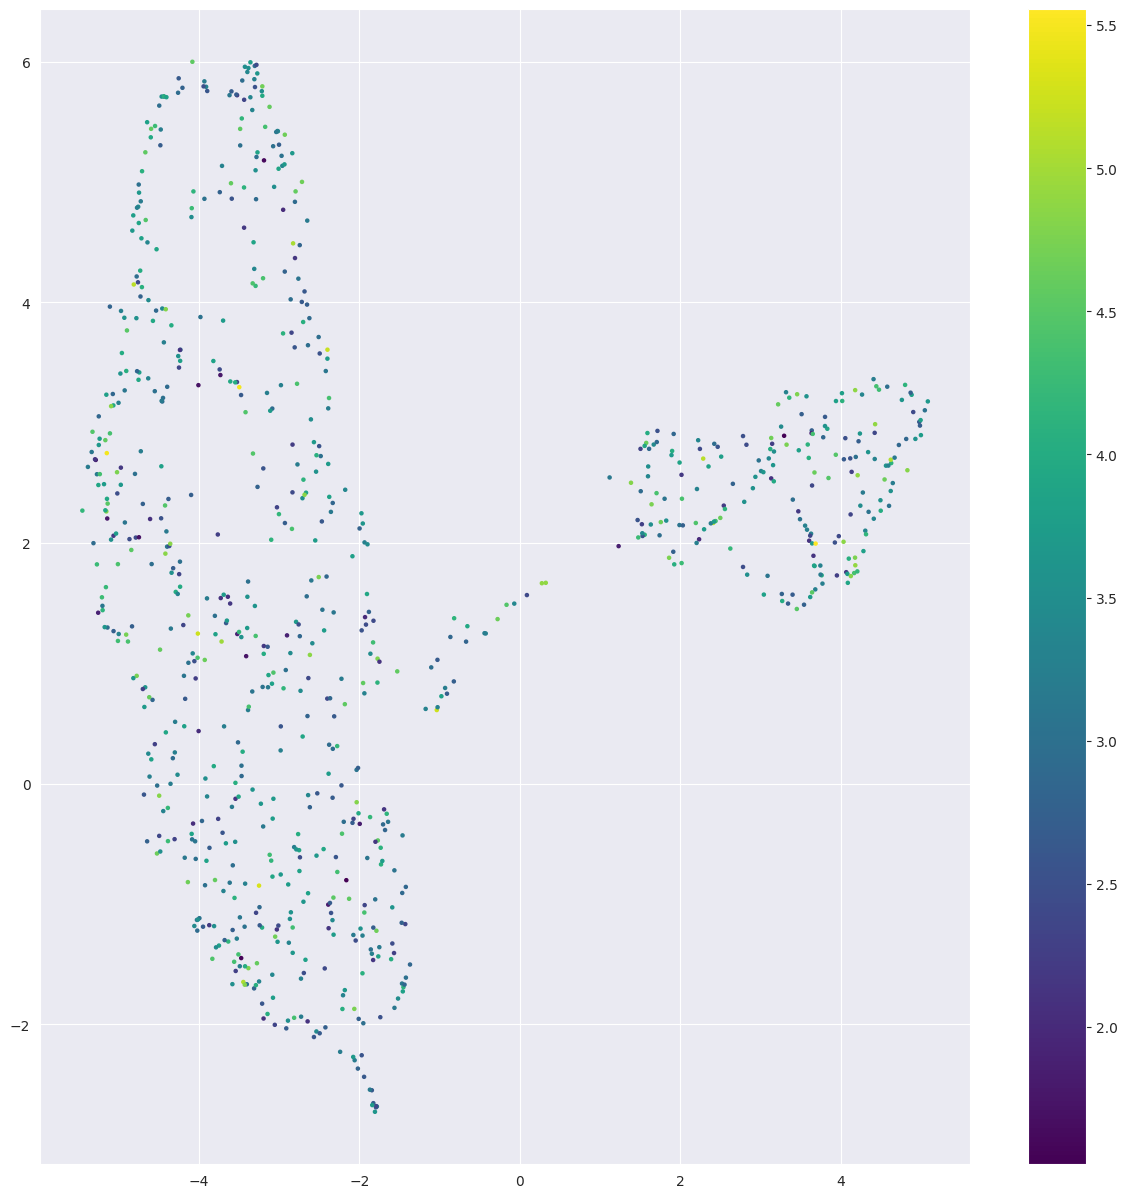

In [75]:
import matplotlib.pyplot as plt

embedding = pd.read_csv('/gamma/Dropbox (GIN)/EMUSE/faces_umap_output_42/faces_embedding_42.csv', header=None).to_numpy()

filtered_files_df = pd.read_csv('/gamma/Dropbox (GIN)/EMUSE/faces/filtered_files.csv')

path_model_match = json.load(open(os.path.join(output_folder, 'path_model_match.json')))

attractive_embedding = embedding[[i for i, img_name in enumerate(filtered_files_df['image_path']) if Path(img_name).name in path_model_match.keys()]]

model_df = pd.read_csv('/gamma/Dropbox (GIN)/EMUSE/faces_umap_output_42/models_merged_df.csv')

# plot the embedding with the attractive column as colour (and a colourbar)
variable = 'Attractive'
# increase figure size
plt.figure(figsize=(15, 15))
plt.scatter(attractive_embedding[:, 0], attractive_embedding[:, 1], c=model_df[variable], cmap='viridis', s=5)
plt.colorbar()
# save the plot
plt.savefig('/gamma/Dropbox (GIN)/EMUSE/faces_umap_output_42/attractive_embedding.png')
plt.show()


In [36]:
import joblib
from tools.inputs_utils import nifti_dataset_to_matrix
import pandas as pd
from pathlib import Path
import os

lesions_folder = '/home/chrisfoulon/neuro_data/NEURAL_DATA/lesion_masks_registered/'
# lesions_folder = '/home/chrisfoulon/neuro_data/NEURAL_DATA/disco/'

spreadsheet = pd.read_excel('/home/chrisfoulon/neuro_data/NEURAL_DATA/NEURAL_CUP_scores_training.xlsx', header=0, index_col=0)

# list nifti files in lesions_folder
lesions_list = [p for p in Path(lesions_folder).iterdir() if p.is_file()]

matched_lesions_list = []
for index in spreadsheet.index:
    found = False
    for i in lesions_list:
        formatted_str = index.replace('-', '')
        # the string must be 6 characters long not more (cut the last character if it is)
        if len(formatted_str) > 6:
            formatted_str = formatted_str[:-1]
        if formatted_str.replace('-', '') in i.name:
            matched_lesions_list.append(i)
            found = True
            break
    if not found:
        print(f'{index} not found')
        
# print columns of spreadsheet
print(spreadsheet.columns)

neural_input_matrix = nifti_dataset_to_matrix(matched_lesions_list)

output_folder = '/home/chrisfoulon/neuro_data/umap_tests_les/'

# load umap from /home/chrisfoulon/neuro_data/umap_tests_les/trained_umap.sav
trained_umap = joblib.load(os.path.join(output_folder, 'trained_umap.sav'))

# embed the neural_input_matrix with the trained umap
les_embeddings = trained_umap.transform(neural_input_matrix)


Index(['MOCA tot M12', 'Visuospatial M12', 'Denomination M12', 'Attention M12',
       'Langage M12', 'Abstraction M12', 'Rappel M12', 'Orientation M12',
       'Isaac M12', 'FM tot M12', 'FM moteur M12', 'HAD_A M12', 'HAD_D M12'],
      dtype='object')


187it [00:04, 46.08it/s]


There is an overlap of 3.74% points in the discrete space
The number of cells in the discrete space is 5035
The shape of the discrete space is (95, 53)
Maximum in each dimension: 12.373346328735352
delete_heatmap: No heatmap with the name neural_heatmap exists


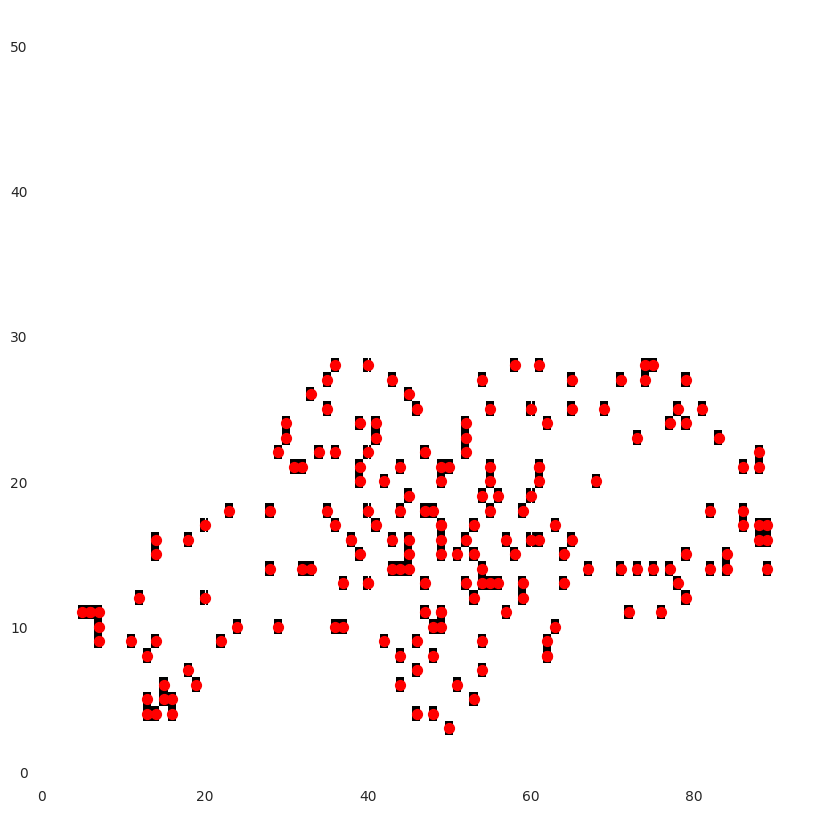

Smoothing the discrete space with a sigma of 1.6986436005760381
Shape of the smoothed space: (187, 95, 53)
Sigma tuple: (0, 1.6986436005760381, 1.6986436005760381)
Shape of the smoothed n+1 dim discrete space: (187, 95, 53)
Max value in the smoothed_nplusone_dim_discrete_space: 0.05517105800002826


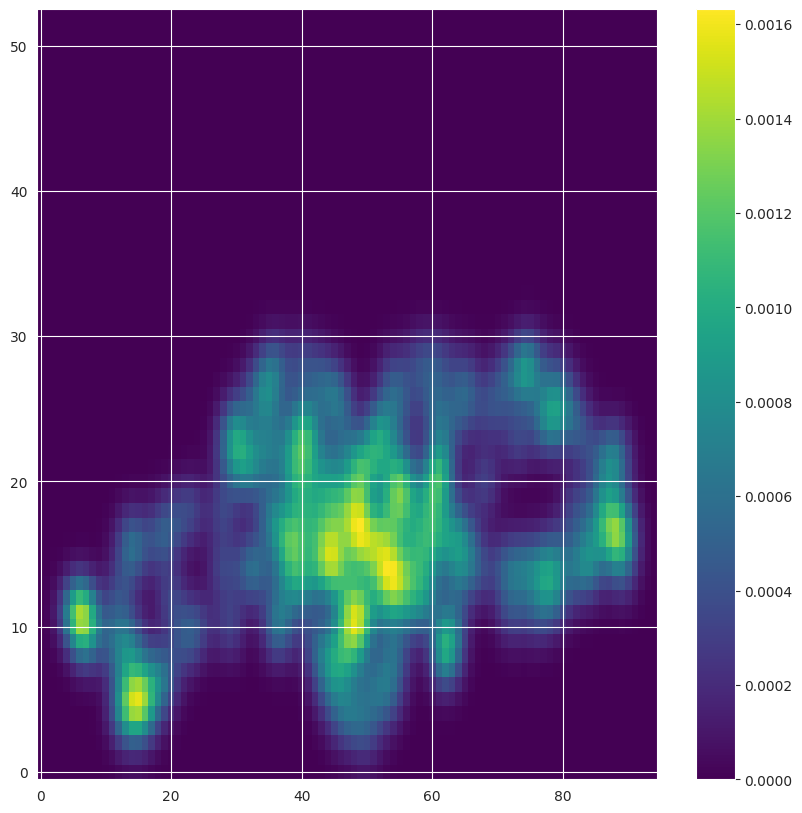

In [37]:
from tools.emuse_utils import DiscreteLatentSpace

test = "MOCA tot M12"
# test_scores needs to be a list
test_scores = spreadsheet[test].tolist()

# create the DiscreteLatentSpace object
dls = DiscreteLatentSpace(trained_umap, les_embeddings, margin=5)

# rescale the embedding
dls.rescale_embedding(dls.raw_embeddings)

# create the discrete space
dls.create_discrete_space(dls.rescaled_embeddings, 5)

# create the heatmap
dls.delete_heatmap('neural_heatmap')
dls.create_heatmap_spaces(dls.raw_embeddings, test_scores, 'neural_heatmap')

# plot the heatmap
dls.plot_discrete_embedding(heatmap_name='neural_heatmap')

# plot the heatmap
dls.plot_heatmap('neural_heatmap', 4)


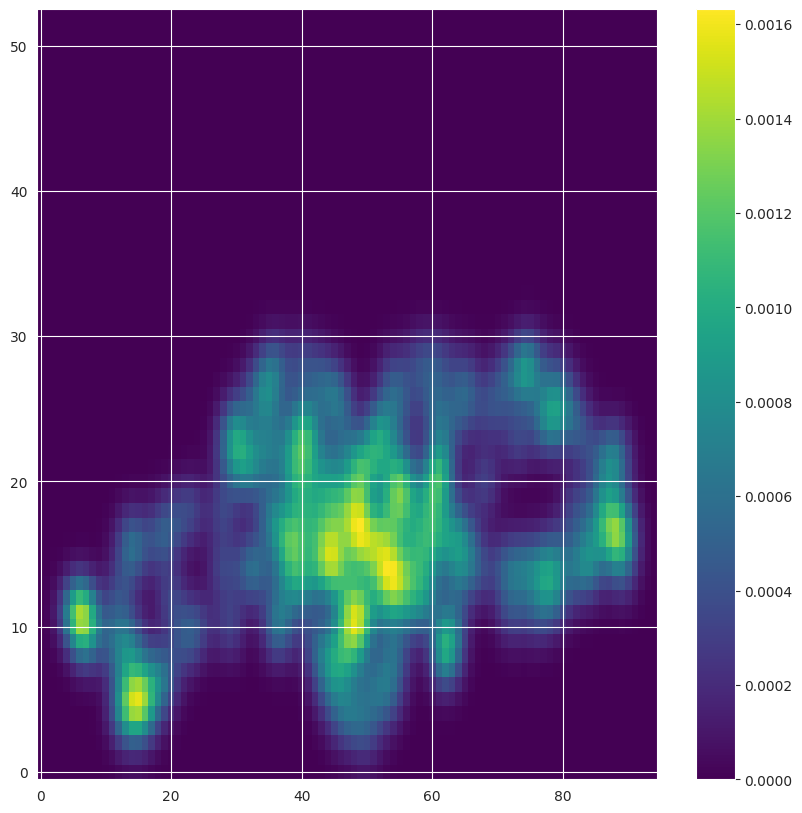

unique_vectors shape: (2894, 187)
vectors shape: (5035, 187)


/home/chrisfoulon/miniconda3/lib/python3.11/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))


 Min max corrected_pvalues: nan nan
<class 'numpy.ndarray'>
Shape corrected_pvalues: (95, 53)
Number of non-Nan values: 2897
Number of non-Nan values: 2897


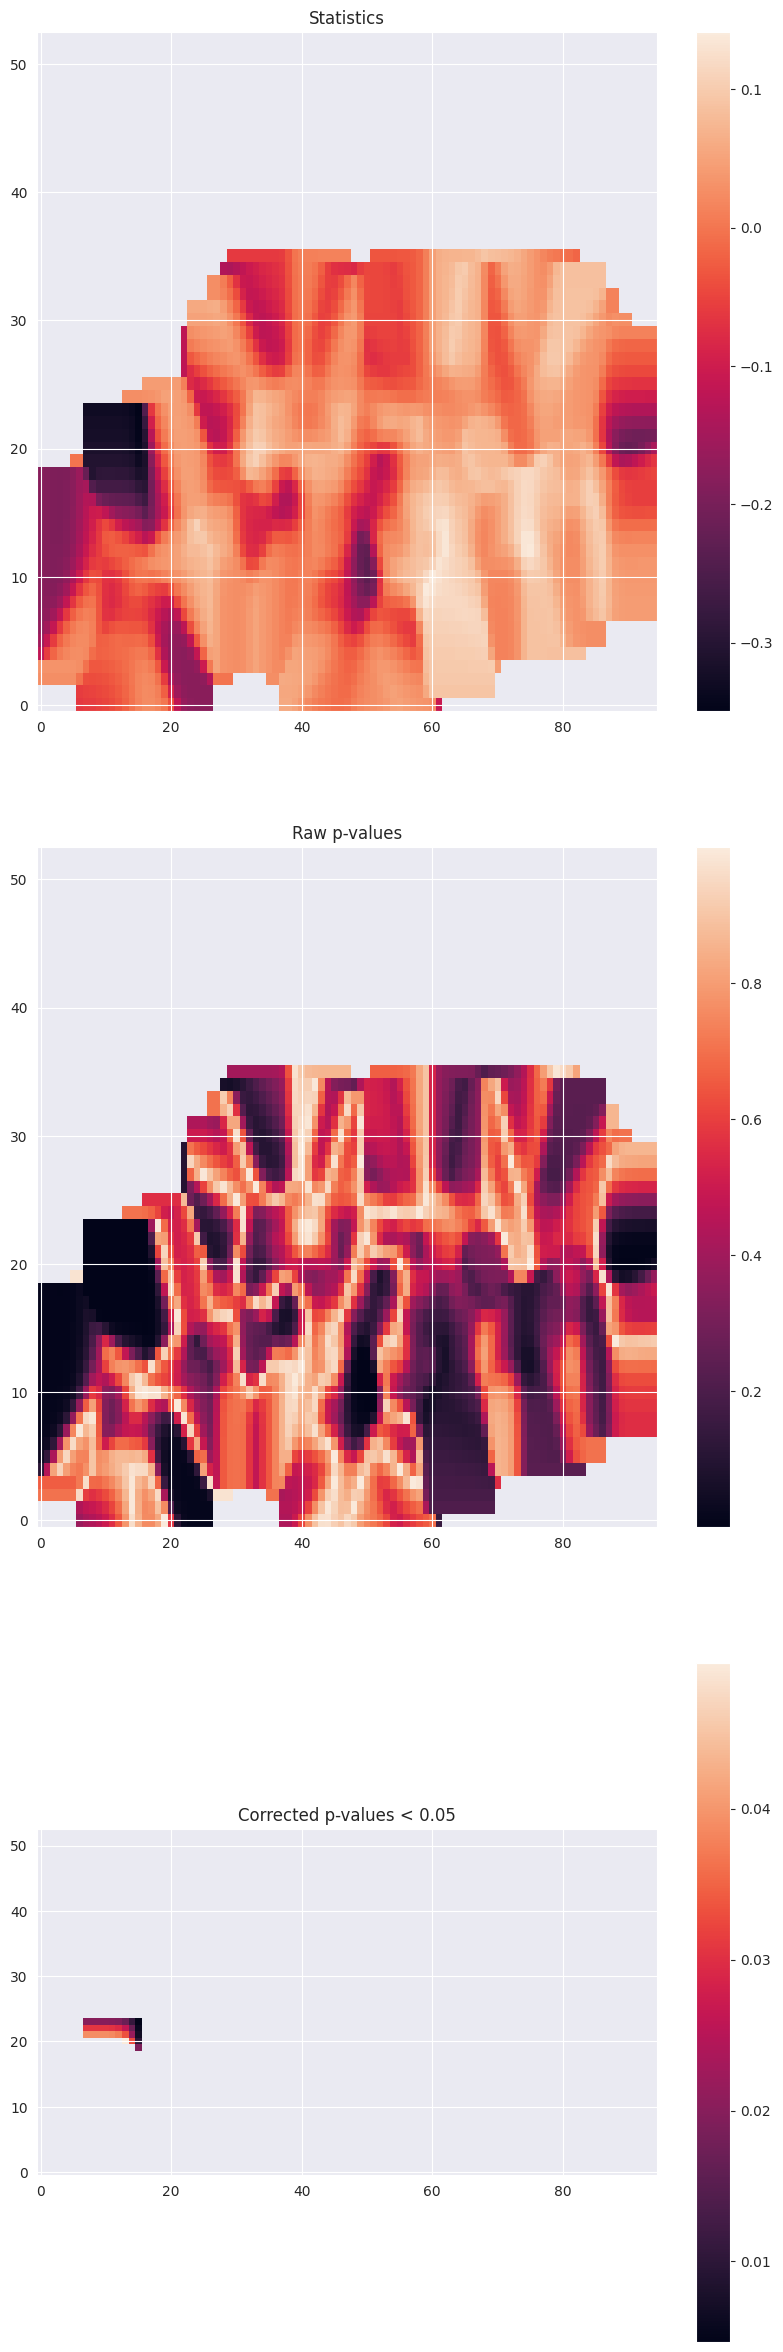

In [40]:
# compute the statistics and corrected p-values
import numpy as np
from tools.emuse_utils import compute_stats_on_smoothed_nplusone_dim_discrete_space, compute_stats_on_corrected_clusters

multiple_comparison_correction = 'sidak'

# plot the heatmap
dls.plot_heatmap('neural_heatmap', 10)

statistics, pvalues, corrected_pvalues, _ = compute_stats_on_smoothed_nplusone_dim_discrete_space(dls.heatmaps['neural_heatmap'], test_scores, 'pearson', multiple_comparison_correction)

statistics_clu, pvalues_clu, corrected_pvalues_clu, _ = compute_stats_on_corrected_clusters(dls.heatmaps['neural_heatmap'], test_scores, 'pearson', multiple_comparison_correction)

# plot the statistics and the corrected p-values heatmap (it is not from the dls class!)

import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(3, 1, figsize=(10, 30))

# Statistics
im = ax[0].imshow(statistics.T, origin='lower', aspect='auto')
ax[0].set_title('Statistics')
fig.colorbar(im, ax=ax[0])
plt.axis('scaled')

# Raw p-values
im = ax[1].imshow(pvalues.T, origin='lower', aspect='auto')
ax[1].set_title('Raw p-values')
fig.colorbar(im, ax=ax[1])
plt.axis('scaled')

print(f' Min max corrected_pvalues: {corrected_pvalues.min()} {corrected_pvalues.max()}')
print(type(corrected_pvalues))
print(f'Shape corrected_pvalues: {corrected_pvalues.shape}')

# check if there are any non-Nan values
print(f'Number of non-Nan values: {np.sum(~np.isnan(corrected_pvalues))}')

if np.sum(~np.isnan(corrected_pvalues)) > 0:
    print(f'Number of non-Nan values: {np.sum(~np.isnan(corrected_pvalues))}')
    masked_corrected_pvalues = np.where(corrected_pvalues < 0.05, corrected_pvalues, np.nan)
    im = ax[2].imshow(masked_corrected_pvalues.T, origin='lower', aspect='auto')
    ax[2].set_title('Corrected p-values < 0.05')
elif np.sum(~np.isnan(corrected_pvalues_clu)) > 0:
    print(f'Number of non-Nan values (clusters): {np.sum(~np.isnan(corrected_pvalues_clu))}')
    masked_corrected_pvalues_clu = np.where(corrected_pvalues_clu < 0.05, corrected_pvalues_clu, np.nan)
    im = ax[2].imshow(masked_corrected_pvalues_clu.T, origin='lower', aspect='auto')
    ax[2].set_title('Corrected p-values clusters < 0.05')
else:
    print(f'Number of non-Nan values (raw p-values): {np.sum(pvalues < 0.05)}')
    masked_pvalues = np.where(pvalues < 0.05, pvalues, np.nan)
    im = ax[2].imshow(masked_pvalues.T, origin='lower', aspect='auto')
    ax[2].set_title('Raw p-values < 0.05')

fig.colorbar(im, ax=ax[2])
plt.axis('scaled')
plt.show()

In [4]:
from joblib import __version__ as joblib_version

print(joblib_version)

1.3.1
